In [ ]:
!pip install kaggle

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{\r\n  "username": "pkaasimahmed",\r\n  "key": "KGAT_c5f7ad6d2b29de9e06427228b7626b7a"\r\n}'}

In [ ]:
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [ ]:
!kaggle datasets download -d yousefmohamed20/sentiment-images-classifier

Dataset URL: https://www.kaggle.com/datasets/yousefmohamed20/sentiment-images-classifier
License(s): apache-2.0
sentiment-images-classifier.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip sentiment-images-classifier.zip

Archive:  sentiment-images-classifier.zip
replace 6 Emotions for image classification/anger/-win-holding-his-fists-shout-wow-mature-hispanic-man-happy-his-win-122652456.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: 6 Emotions for image classification/anger/-win-holding-his-fists-shout-wow-mature-hispanic-man-happy-his-win-122652456.jpg  
  inflating: 6 Emotions for image classification/anger/GBP-scam.jpg  
  inflating: 6 Emotions for image classification/anger/I-hate-my-job.jpeg  
  inflating: 6 Emotions for image classification/anger/Learn-How-to-Protect-Yourself-from-Aggressive-Drivers-on-the-Road-1024x683.jpg  
  inflating: 6 Emotions for image classification/anger/OIP.0846U2L7OhuSwKhrPv2QyAHaE8.jpg  
  inflating: 6 Emotions for image classification/anger/OIP.2U-VMhf313UA984u5UOmFgHaE8.jpg  
  inflating: 6 Emotions for image classification/anger/OIP.4KY2OX8QTAff8PFMslU-rQHaFU.jpg  
  inflating: 6 Emotions for image classification/anger/OIP.5HgV6R-8EQ-LPrPMTjVxJwHaLH.jpg 

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

In [ ]:
IMG_SIZE = 128
BATCH_SIZE = 32

data_path = "/content/6 Emotions for image classification"

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

test_data = datagen.flow_from_directory(
    data_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 922 images belonging to 6 classes.
Found 226 images belonging to 6 classes.


In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(IMG_SIZE,IMG_SIZE,3)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(128,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(256,activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(train_data.num_classes,activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=15
)

Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 14s 365ms/step - accuracy: 0.1603 - loss: 1.9056 - val_accuracy: 0.2124 - val_loss: 1.7567
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 266ms/step - accuracy: 0.2614 - loss: 1.7469 - val_accuracy: 0.3274 - val_loss: 1.6114
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.3696 - loss: 1.5977 - val_accuracy: 0.3584 - val_loss: 1.5758
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 270ms/step - accuracy: 0.4271 - loss: 1.4417 - val_accuracy: 0.3717 - val_loss: 1.5962
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 260ms/step - accuracy: 0.5750 - loss: 1.1396 - val_accuracy: 0.3540 - val_loss: 1.7866
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 246ms/step - accuracy: 0.7079 - loss: 0.8832 - val_accuracy: 0.3717 - val_loss: 1.9581
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.7540 - loss: 0.6845 - val_accuracy: 0.3805 - val_loss: 2.2781
Epoch 8/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step - accuracy: 0.8441 - loss: 0.4747 - val_accuracy: 0

In [ ]:
model.save("sentiment_cnn_model.keras")

In [ ]:
from tensorflow.keras.models import load_model

model = load_model("sentiment_cnn_model.keras")

In [132]:
from google.colab import files
uploaded = files.upload()

Saving low-view-man-being-extremely-happy_23-2148648186.avif to low-view-man-being-extremely-happy_23-2148648186 (6).avif


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


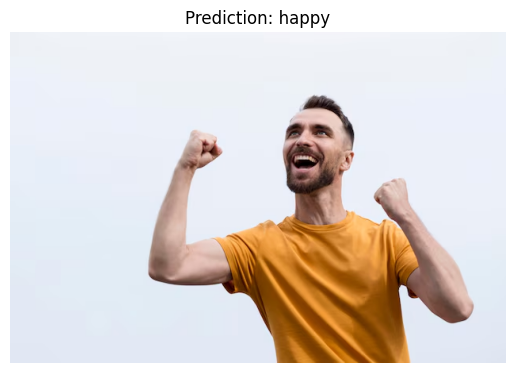

In [133]:
class_names = list(train_data.class_indices.keys())

for img_name in uploaded.keys():

    img = cv2.imread(img_name)
    img = cv2.resize(img,(IMG_SIZE,IMG_SIZE))
    img = img/255.0
    img = np.expand_dims(img,axis=0)

    prediction = model.predict(img)
    class_index = np.argmax(prediction)

    plt.imshow(cv2.cvtColor(cv2.imread(img_name),cv2.COLOR_BGR2RGB))
    plt.title("Prediction: " + class_names[class_index])
    plt.axis("off")
    plt.show()